In [7]:
# =============================
# 1. IMPORTS
# =============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv2D, MaxPooling2D,
                                     BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import kagglehub

np.random.seed(42)
tf.random.set_seed(42)

print("Setup done ✅")


Setup done ✅


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
!pip uninstall kagglehub -y
!pip install kagglehub

Found existing installation: kagglehub 0.3.13
Uninstalling kagglehub-0.3.13:
  Successfully uninstalled kagglehub-0.3.13
  Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)


You should consider upgrading via the 'c:\users\hp\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [8]:
# =============================
# 2. DATASET
# =============================
path = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")

train_path = os.path.join(path, "Train")
test_path = os.path.join(path, "Test-A")

classes = ["Neutrophil", "Lymphocyte", "Monocyte", "Eosinophil", "Basophil"]

print("Dataset ready ✅")

Dataset ready ✅


In [10]:
# =============================
# 3. DATA GENERATORS
# =============================

img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Generators ready ✅")

Found 8142 images belonging to 5 classes.
Found 2033 images belonging to 5 classes.
Found 4339 images belonging to 5 classes.
Generators ready ✅


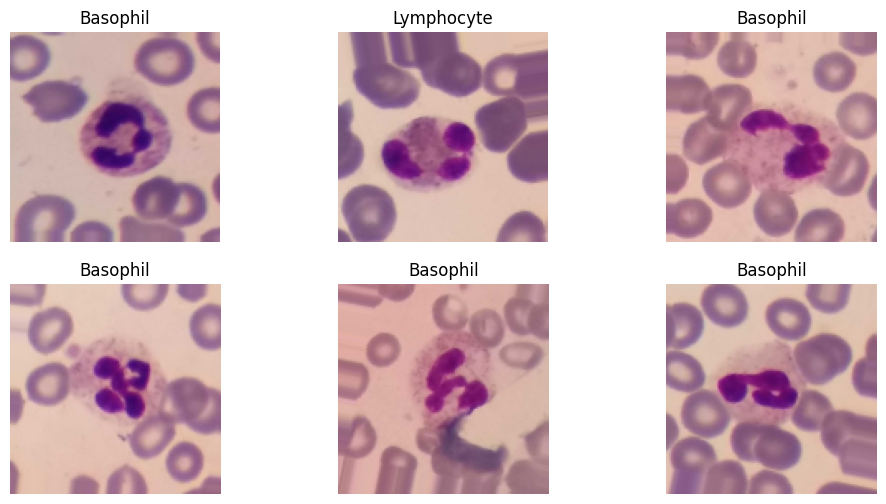

In [11]:
# =============================
# 4. VISUALIZATION
# =============================
images, labels = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

In [12]:
# =============================
# 5. CNN MODEL
# =============================

model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),  # أفضل من Flatten
    
    Dense(256, activation='relu'),
    Dropout(0.5),
    
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 64, 64, 64)        256       
 chNormalization)                                                
                                                      

In [13]:
# =============================
# 6. CALLBACKS
# =============================

callbacks = [
    ModelCheckpoint("best_cnn_model.keras", save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3)
]

In [14]:
# =============================
# 7. TRAINING
# =============================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30


255/255 [==============================] - 132s 498ms/step - loss: 0.4882 - accuracy: 0.8233 - val_loss: 1.6862 - val_accuracy: 0.2391 - lr: 5.0000e-04
Epoch 2/30
255/255 [==============================] - 115s 449ms/step - loss: 0.1847 - accuracy: 0.9394 - val_loss: 0.6720 - val_accuracy: 0.7624 - lr: 5.0000e-04
Epoch 3/30
255/255 [==============================] - 113s 442ms/step - loss: 0.1315 - accuracy: 0.9554 - val_loss: 0.5377 - val_accuracy: 0.8210 - lr: 5.0000e-04
Epoch 4/30
255/255 [==============================] - 116s 454ms/step - loss: 0.1123 - accuracy: 0.9651 - val_loss: 0.8524 - val_accuracy: 0.7216 - lr: 5.0000e-04
Epoch 5/30
255/255 [==============================] - 116s 453ms/step - loss: 0.0954 - accuracy: 0.9656 - val_loss: 1.0164 - val_accuracy: 0.6936 - lr: 5.0000e-04
Epoch 6/30
255/255 [==============================] - 166s 651ms/step - loss: 0.0925 - accuracy: 0.9700 - val_loss: 0.4134 - val_accuracy: 0.8598 - lr: 5.0000e-04
Epoch 7/30
255/255 [

In [15]:
# =============================
# 8. EVALUATION
# =============================

test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

136/136 [==============================] - 41s 301ms/step - loss: 0.0980 - accuracy: 0.9659
Test Accuracy: 0.9658907651901245


136/136 [==============================] - 45s 326ms/step
              precision    recall  f1-score   support

  Neutrophil       1.00      0.99      0.99        89
  Lymphocyte       0.96      0.84      0.90       322
    Monocyte       0.98      0.97      0.98      1034
  Eosinophil       0.92      0.78      0.85       234
    Basophil       0.96      0.99      0.98      2660

    accuracy                           0.97      4339
   macro avg       0.97      0.92      0.94      4339
weighted avg       0.97      0.97      0.96      4339



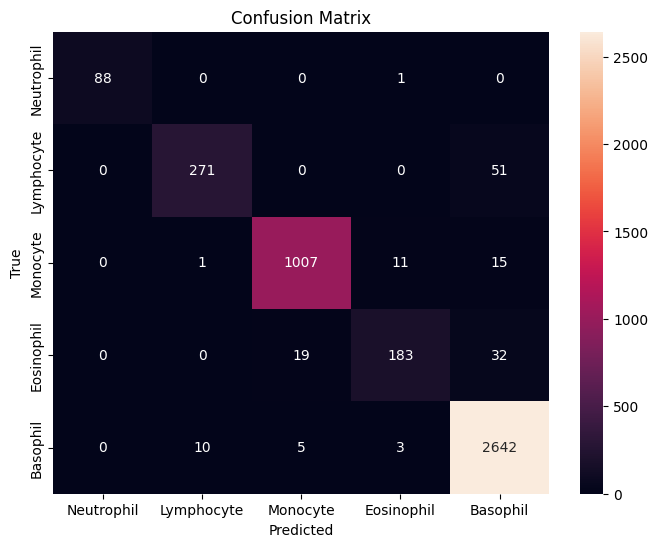

In [16]:
# =============================
# 9. METRICS
# =============================

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_classes, target_names=classes))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

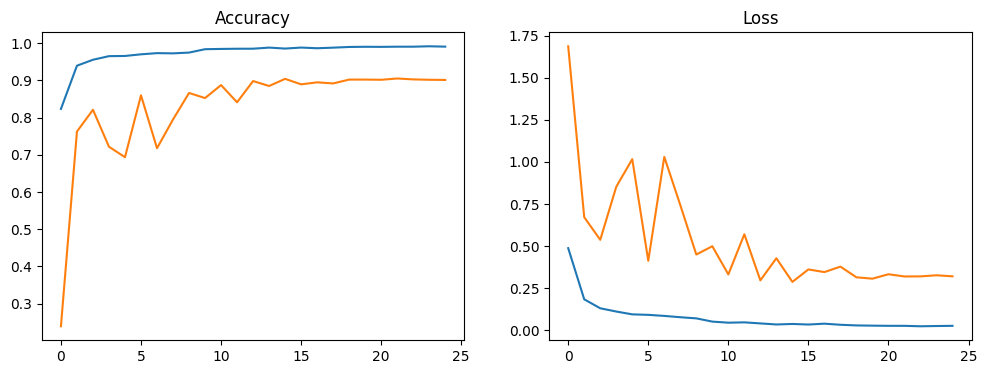

In [17]:
# =============================
# 10. HISTORY
# =============================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.show()

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Use the classes order from the train_generator
classes = list(train_generator.class_indices.keys())
print("Classes order:", classes)

def predict_image(img_path):
    # Load image and convert to RGB
    img = Image.open(img_path).convert("RGB").resize((128,128))
    
    # Normalize image
    img_array = np.array(img)/255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    pred = model.predict(img_array)
    cls_index = np.argmax(pred)
    
    # Print prediction
    print(f"Prediction: {classes[cls_index]} ({pred[0][cls_index]*100:.2f}%)")
    
    # Show image
    plt.imshow(img_array[0])
    plt.title(classes[cls_index])
    plt.axis('off')
    plt.show()

Classes order: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


1/1 [==============================] - 0s 52ms/step
Prediction: Basophil (99.98%)


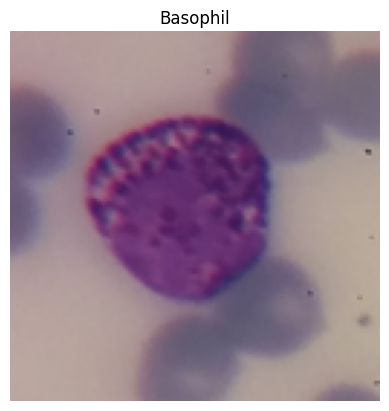

In [23]:
predict_image("20190526_163545_0.jpg")


Predicting 20190526_163027_0.jpg ...
1/1 [==============================] - 0s 37ms/step
Prediction: Basophil (100.00%)


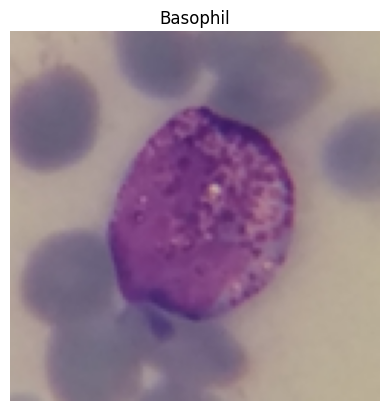


Predicting 20190526_163055_0.jpg ...
1/1 [==============================] - 0s 48ms/step
Prediction: Basophil (100.00%)


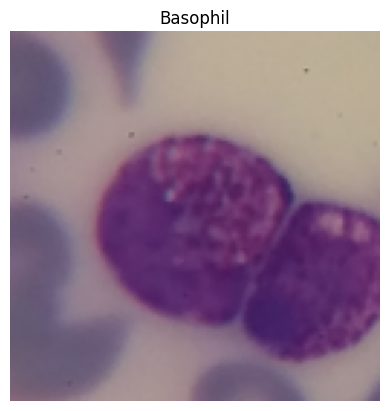


Predicting 20190526_163055_1.jpg ...
1/1 [==============================] - 0s 45ms/step
Prediction: Basophil (100.00%)


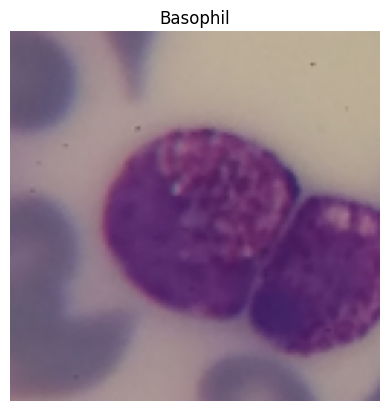


Predicting 20190526_163055_2.jpg ...
1/1 [==============================] - 0s 27ms/step
Prediction: Basophil (100.00%)


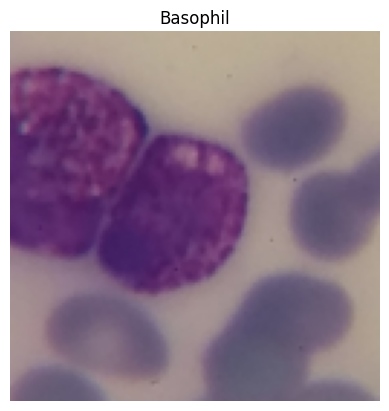


Predicting 20190526_163545_0.jpg ...
1/1 [==============================] - 0s 54ms/step
Prediction: Basophil (99.98%)


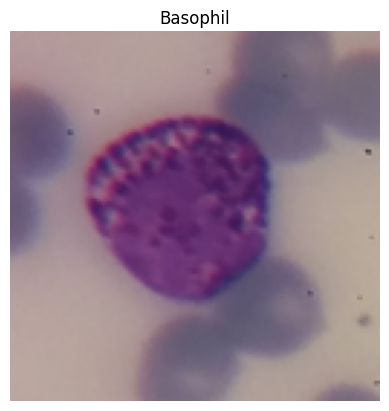


Predicting 20190526_163656_0.jpg ...
1/1 [==============================] - 0s 57ms/step
Prediction: Basophil (100.00%)


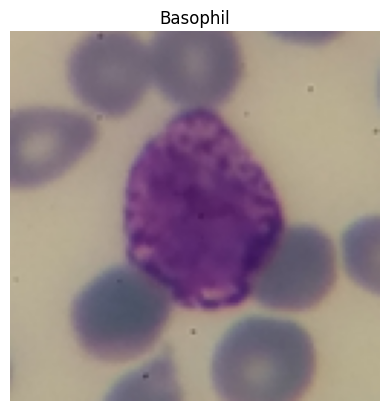


Predicting 20190526_163835_0.jpg ...
1/1 [==============================] - 0s 51ms/step
Prediction: Basophil (100.00%)


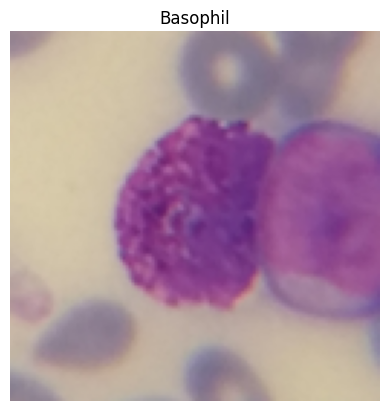


Predicting 20190526_163835_1.jpg ...
1/1 [==============================] - 0s 54ms/step
Prediction: Basophil (100.00%)


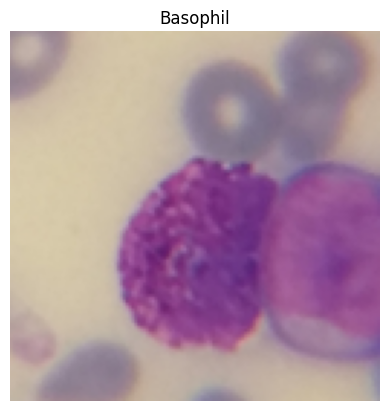


Predicting 20190526_164040_0.jpg ...
1/1 [==============================] - 0s 38ms/step
Prediction: Basophil (100.00%)


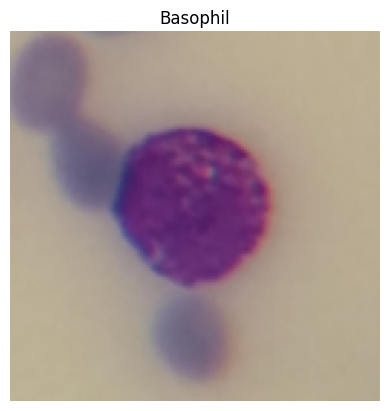


Predicting 20190526_164638_0.jpg ...
1/1 [==============================] - 0s 32ms/step
Prediction: Basophil (99.99%)


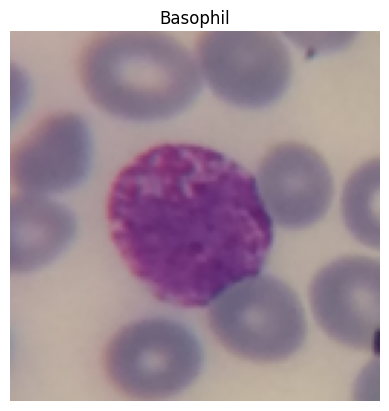

In [26]:
import os

# path للفولدر اللي فيه الصور
folder_path = r"E:\projectbiooo\archive\Test-A\Basophil"  # غيره بالمسار الصح

# احصل على كل الصور في الفولدر (png, jpg, jpeg)
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# خد أول 20 صورة فقط
image_files = image_files[:10]

for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)
    print(f"\nPredicting {img_name} ...")
    predict_image(img_path)


Predicting 95-8-12-2_112_1.jpg ...
1/1 [==============================] - 0s 48ms/step
Prediction: Lymphocyte (100.00%)


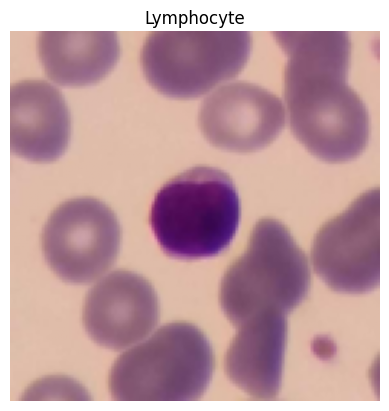


Predicting 95-8-12-2_116_2.jpg ...
1/1 [==============================] - 0s 48ms/step
Prediction: Lymphocyte (100.00%)


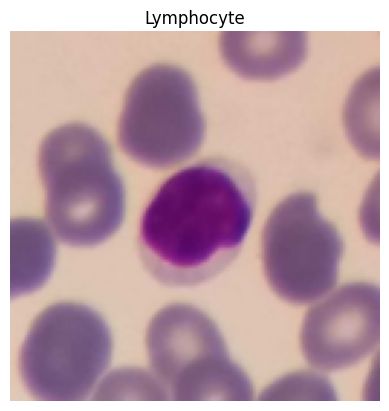


Predicting 95-8-12-2_124_1.jpg ...
1/1 [==============================] - 0s 51ms/step
Prediction: Lymphocyte (100.00%)


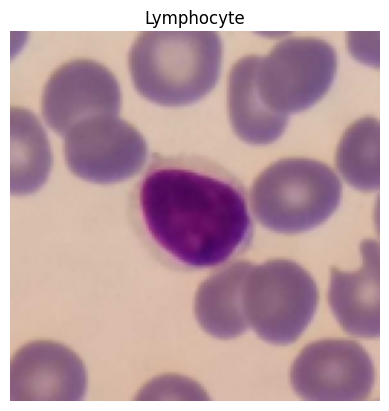


Predicting 95-8-12-2_31_1.jpg ...
1/1 [==============================] - 0s 43ms/step
Prediction: Lymphocyte (100.00%)


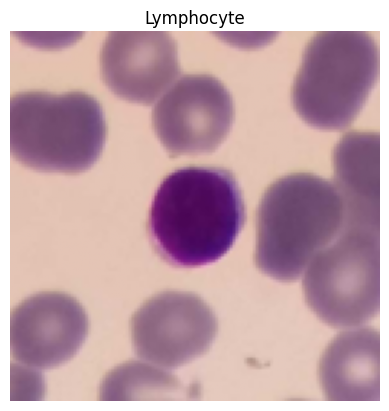


Predicting 95-8-12-2_43_1.jpg ...
1/1 [==============================] - 0s 73ms/step
Prediction: Lymphocyte (100.00%)


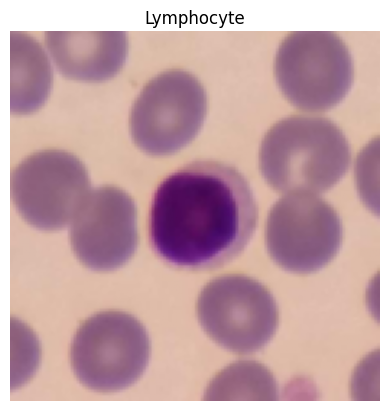


Predicting 95-8-12-3_123_1.jpg ...
1/1 [==============================] - 0s 36ms/step
Prediction: Lymphocyte (99.37%)


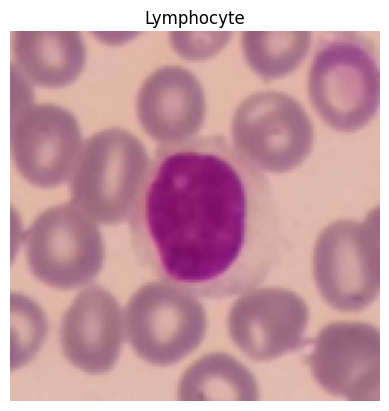


Predicting 95-8-12-3_42_1.jpg ...
1/1 [==============================] - 0s 50ms/step
Prediction: Lymphocyte (99.15%)


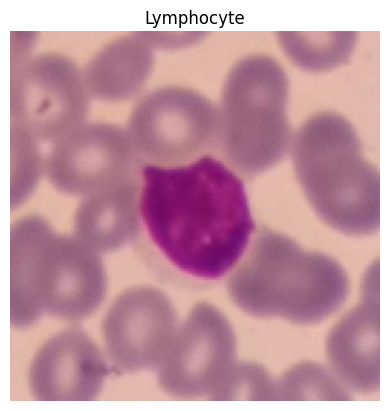


Predicting 95-8-12-3_83_1.jpg ...
1/1 [==============================] - 0s 40ms/step
Prediction: Lymphocyte (99.52%)


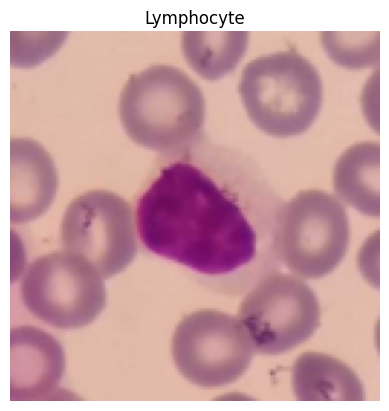


Predicting 95-8-12-3_95_1.jpg ...
1/1 [==============================] - 0s 26ms/step
Prediction: Lymphocyte (93.94%)


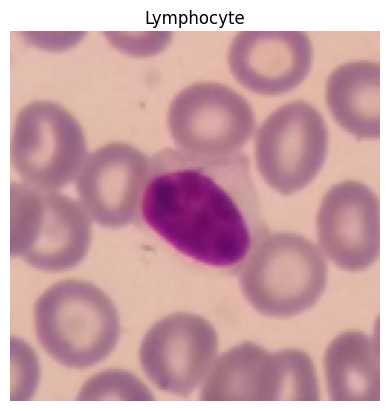


Predicting 95-8-12-3_98_1.jpg ...
1/1 [==============================] - 0s 51ms/step
Prediction: Lymphocyte (99.97%)


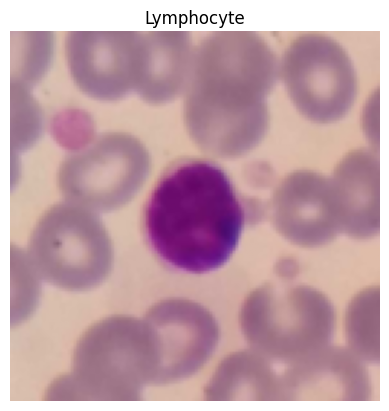

In [28]:
import os

# path للفولدر اللي فيه الصور
folder_path = r"E:\projectbiooo\archive\Test-A\Lymphocyte"  # غيره بالمسار الصح

# احصل على كل الصور في الفولدر (png, jpg, jpeg)
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# خد أول 20 صورة فقط
image_files = image_files[:10]

for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)
    print(f"\nPredicting {img_name} ...")
    predict_image(img_path)

In [29]:
# حفظ الموديل
model.save("my_cnn_model")  # هيتحفظ فولدر اسمه my_cnn_model
print("✅ Model saved successfully!")

INFO:tensorflow:Assets written to: my_cnn_model\assets


INFO:tensorflow:Assets written to: my_cnn_model\assets


✅ Model saved successfully!


In [ ]:
cwd = os.getcwd()
print("Current working directory:", cwd)

model_path = os.path.join(cwd, "my_cnn_model")
print("Model saved at:", model_path)

Current working directory: e:\
Model saved at: e:\my_cnn_model


In [31]:
# حفظ الموديل كملف واحد بصيغة Keras
model.save("my_model2.keras")
print("✅ Model saved as my_model2.keras")

✅ Model saved as my_model2.keras


In [32]:
cwd = os.getcwd()
print("Current working directory:", cwd)

model_path = os.path.join(cwd, "my_model2.keras")
print("Model saved at:", model_path)

Current working directory: e:\
Model saved at: e:\my_model2.keras
